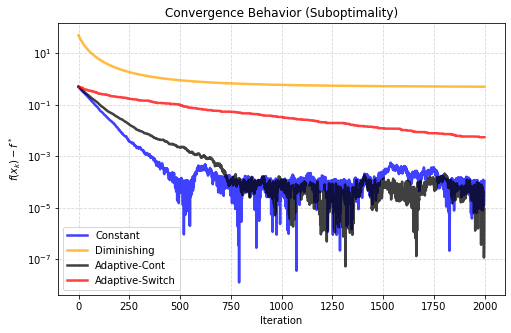

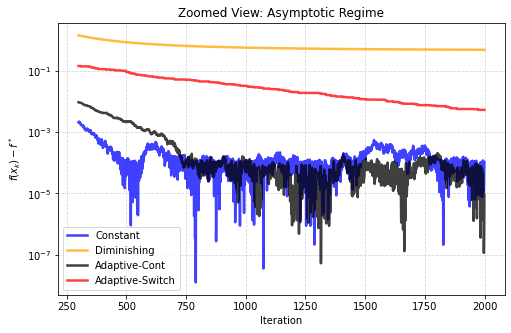

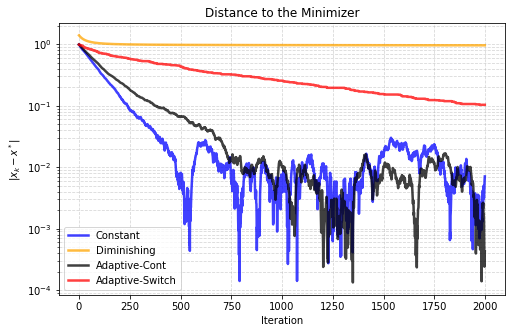

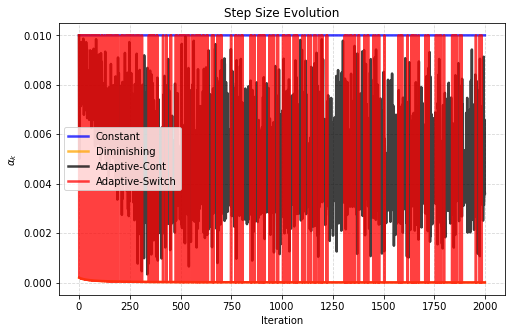

In [14]:
import matplotlib.pyplot as plt
import numpy as np
# ============================================================
# Reproducibility
# ============================================================
np.random.seed(0)

# ============================================================
# Problem setup: strongly convex quadratic
# ============================================================
A = np.array([[1, 0],
              [0, 100]])          # SPD matrix

eigvals = np.linalg.eigvalsh(A)
mu = eigvals.min()
L = eigvals.max()

def f(x):
    return 0.5 * x @ A @ x

def grad(x):
    return A @ x

x_star = np.zeros(2)
x0 = np.array([1.0, 1.0])

K = 2000
eps = 0.15       # gradient error magnitude

# ============================================================
# Correlated bounded gradient error (IMPORTANT)
# ============================================================
e = np.zeros(2)

def bounded_error_corr(rho=0.2):
    global e
    e = rho * e + np.sqrt(1 - rho**2) * np.random.randn(2)
    return eps * e / (np.linalg.norm(e) + 1e-8)

# ============================================================
# Step size rules
# ============================================================
alpha_const = 1.0 / L

def alpha_diminishing(k, c=1.0 / L, beta=50):
    return c / (k + beta)

def alpha_adaptive_cont(rel_dk, c=1.0 / L, amin=1e-4, amax=1.0 / L):
    return np.clip(c / (1.0 + rel_dk), amin, amax)

def alpha_adaptive_switch(rk, k, c=1.0 / L, tau=0.1, amax=1.0 / L, k0=50):
    if rk <= tau:
        return amax
    else:
        return min(amax, c / (k + k0))

# ============================================================
# Inexact gradient descent
# ============================================================
def run(method):
    x = x0.copy()
    g_prev = grad(x) + bounded_error_corr()

    fvals, dists, alphas = [], [], []

    for k in range(K):
        g = grad(x) + bounded_error_corr()

        if method == "constant":
            alpha = alpha_const

        elif method == "diminishing":
            alpha = alpha_diminishing(k)

        elif method == "adaptive_cont":
            rel_dk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g_prev) + 1e-8)
            alpha = alpha_adaptive_cont(rel_dk)

        elif method == "adaptive_switch":
            rk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g) + 1e-8)
            alpha = alpha_adaptive_switch(rk, k)

        x = x - alpha * g

        fvals.append(f(x) - f(x_star))
        dists.append(np.linalg.norm(x - x_star))
        alphas.append(alpha)

        g_prev = g

    return np.array(fvals), np.array(dists), np.array(alphas)

# ============================================================
# Run experiments
# ============================================================
results = {
    "Constant": run("constant"),
    "Diminishing": run("diminishing"),
    "Adaptive-Cont": run("adaptive_cont"),
    "Adaptive-Switch": run("adaptive_switch"),
}

color_map = {
    "Constant": "blue",
    "Diminishing": "orange",
    "Adaptive-Cont": "black",
    "Adaptive-Switch": "red",
}

# ============================================================
# Plot settings
# ============================================================
line_kw = dict(lw=2.5, alpha=0.75)

# ============================================================
# Figure 1: Suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, (fvals, _, _) in results.items():
    plt.semilogy(fvals, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Convergence Behavior (Suboptimality)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 2: Zoomed Suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, (fvals, _, _) in results.items():
    plt.semilogy(range(300, K), fvals[300:], label=name,
                 color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Zoomed View: Asymptotic Regime")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 3: Distance to minimizer
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, dists, _) in results.items():
    plt.semilogy(dists, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$\|x_k - x^*\|$")
plt.title("Distance to the Minimizer")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 4: Step size evolution
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, _, alphas) in results.items():
    plt.plot(alphas, label=name, color=color_map[name], **line_kw)

plt.xlabel("Iteration")
plt.ylabel(r"$\alpha_k$")
plt.title("Step Size Evolution")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()





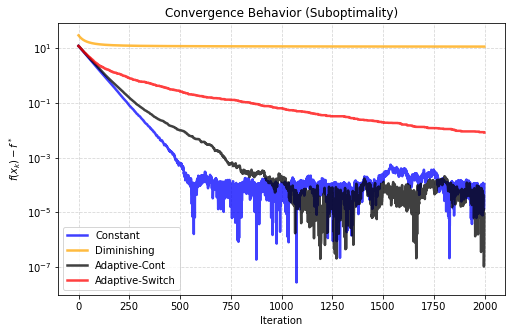

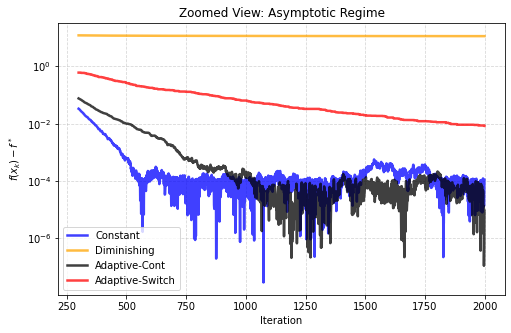

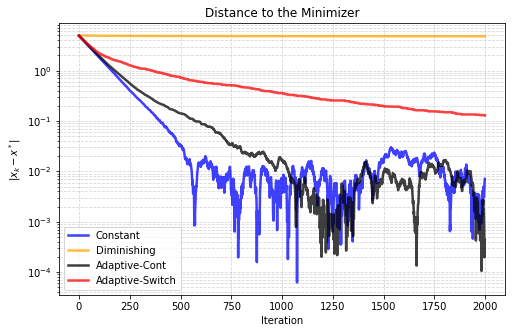

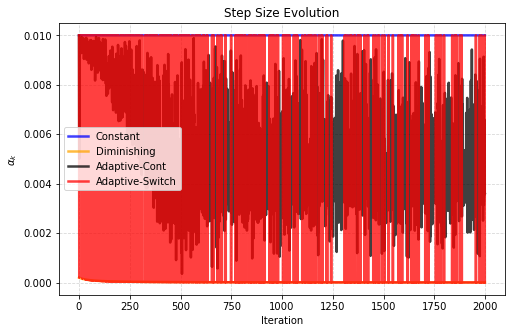

mu = 1.000, L = 100.000, 1/L = 0.0100, eps = 0.15


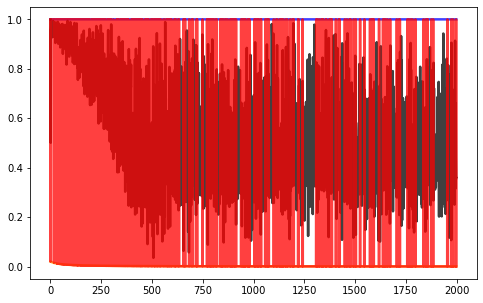

In [8]:
import matplotlib.pyplot as plt
import numpy as np
# ============================================================
# Reproducibility
# ============================================================
np.random.seed(0)

# ============================================================
# Problem setup: strongly convex quadratic
# ============================================================
A = np.array([[1, 0],
              [0, 100]])          # SPD matrix

eigvals = np.linalg.eigvalsh(A)
mu = eigvals.min()
L = eigvals.max()

def f(x):
    return 0.5 * x @ A @ x

def grad(x):
    return A @ x

x_star = np.zeros(2)
theta = np.pi / 6
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])
x0 = R @ np.array([4.0, -3.0])  

K = 2000
eps = 0.15       # gradient error magnitude

# ============================================================
# Correlated bounded gradient error (IMPORTANT)
# ============================================================
e = np.zeros(2)

def bounded_error_corr(rho=0.2):
    global e
    e = rho * e + np.sqrt(1 - rho**2) * np.random.randn(2)
    return eps * e / (np.linalg.norm(e) + 1e-8)

# ============================================================
# Step size rules
# ============================================================
alpha_const = 1.0 / L

def alpha_diminishing(k, c=1.0 / L, beta=50):
    return c / (k + beta)

def alpha_adaptive_cont(rel_dk, c=1.0 / L, amin=1e-4, amax=1.0 / L):
    return np.clip(c / (1.0 + rel_dk), amin, amax)

def alpha_adaptive_switch(rk, k, c=1.0 / L, tau=0.1, amax=1.0 / L, k0=50):
    if rk <= tau:
        return amax
    else:
        return min(amax, c / (k + k0))

# ============================================================
# Inexact gradient descent
# ============================================================
def run(method):
    x = x0.copy()
    g_prev = grad(x) + bounded_error_corr()

    fvals, dists, alphas = [], [], []

    for k in range(K):
        g = grad(x) + bounded_error_corr()

        if method == "constant":
            alpha = alpha_const

        elif method == "diminishing":
            alpha = alpha_diminishing(k)

        elif method == "adaptive_cont":
            rel_dk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g_prev) + 1e-8)
            alpha = alpha_adaptive_cont(rel_dk)

        elif method == "adaptive_switch":
            rk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g) + 1e-8)
            alpha = alpha_adaptive_switch(rk, k)

        x = x - alpha * g

        fvals.append(f(x) - f(x_star))
        dists.append(np.linalg.norm(x - x_star))
        alphas.append(alpha)

        g_prev = g

    return np.array(fvals), np.array(dists), np.array(alphas)

# ============================================================
# Run experiments
# ============================================================
results = {
    "Constant": run("constant"),
    "Diminishing": run("diminishing"),
    "Adaptive-Cont": run("adaptive_cont"),
    "Adaptive-Switch": run("adaptive_switch"),
}

color_map = {
    "Constant": "blue",
    "Diminishing": "orange",
    "Adaptive-Cont": "black",
    "Adaptive-Switch": "red",
}

# ============================================================
# Plot settings
# ============================================================
line_kw = dict(lw=2.5, alpha=0.75)

# ============================================================
# Figure 1: Suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, (fvals, _, _) in results.items():
    plt.semilogy(fvals, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Convergence Behavior (Suboptimality)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 2: Zoomed Suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, (fvals, _, _) in results.items():
    plt.semilogy(range(300, K), fvals[300:], label=name,
                 color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Zoomed View: Asymptotic Regime")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 3: Distance to minimizer
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, dists, _) in results.items():
    plt.semilogy(dists, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$\|x_k - x^*\|$")
plt.title("Distance to the Minimizer")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 4: Step size evolution
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, _, alphas) in results.items():
    plt.plot(alphas, label=name, color=color_map[name], **line_kw)

plt.xlabel("Iteration")
plt.ylabel(r"$\alpha_k$")
plt.title("Step Size Evolution")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 5: Stability diagnostic (CRUCIAL)
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, _, alphas) in results.items():
    plt.plot(alphas * L, label=name, color=color_map[name], **line_kw)


print(f"mu = {mu:.3f}, L = {L:.3f}, 1/L = {1/L:.4f}, eps = {eps}")

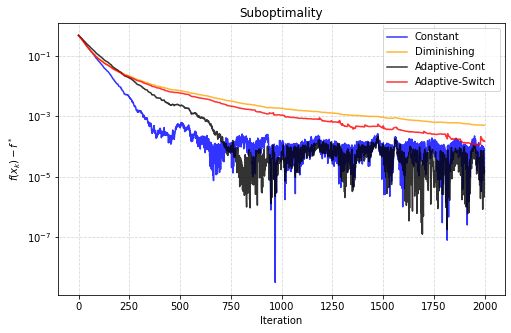

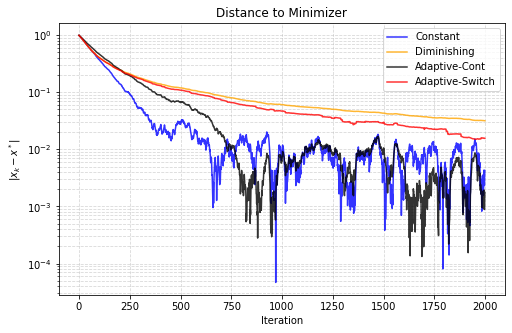

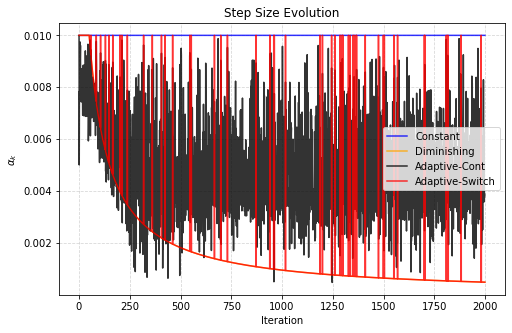

mu = 1.00, L = 100.00, 1/L = 0.0100
Constant        final alpha = 1.00e-02
Diminishing     final alpha = 4.88e-04
Adaptive-Cont   final alpha = 3.88e-03
Adaptive-Switch final alpha = 4.88e-04


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility
# ============================================================
SEED = 0
np.random.seed(SEED)

# ============================================================
# Problem setup: strongly convex quadratic
# ============================================================
A = np.array([[1.0, 0.0],
              [0.0, 100.0]])

eigvals = np.linalg.eigvalsh(A)
mu = eigvals.min()
L = eigvals.max()

def f(x):
    return 0.5 * x @ A @ x

def grad(x):
    return A @ x

x_star = np.zeros(2)
x0 = np.array([1.0, 1.0])
#theta = np.pi / 6
#R = np.array([
#    [np.cos(theta), -np.sin(theta)],
#    [np.sin(theta),  np.cos(theta)]
#])
#x0 = R @ np.array([4.0, -3.0]) 

# ============================================================
# Experiment parameters
# ============================================================
K = 2000
eps = 0.15
rho = 0.2

# ============================================================
# Step size rules
# ============================================================
alpha_const = 1.0 / L

def alpha_diminishing(k, amax=1.0 / L, beta=50):
    """
    Safe diminishing:
    - early iterations behave like constant step
    - asymptotically alpha_k -> 0
    """
    return min(amax, 1.0 / (k + beta))

def alpha_adaptive_cont(rel_dk, amax=1.0 / L, amin=1e-4):
    return np.clip(amax / (1.0 + rel_dk), amin, amax)

def alpha_adaptive_switch(rk, k, amax=1.0 / L, tau=0.1, beta=50):
    if rk <= tau:
        return amax
    return min(amax, 1.0 / (k + beta))

# ============================================================
# Inexact gradient descent runner
# ============================================================
def run(method, seed=0):
    rng = np.random.default_rng(seed)

    # reset correlated error
    e = np.zeros(2)

    def bounded_error():
        nonlocal e
        e = rho * e + np.sqrt(1 - rho**2) * rng.standard_normal(2)
        return eps * e / (np.linalg.norm(e) + 1e-8)

    x = x0.copy()
    g_prev = grad(x) + bounded_error()

    fvals, dists, alphas = [], [], []

    for k in range(K):
        g = grad(x) + bounded_error()

        if method == "constant":
            alpha = alpha_const

        elif method == "diminishing":
            alpha = alpha_diminishing(k)

        elif method == "adaptive_cont":
            rel_dk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g_prev) + 1e-8)
            alpha = alpha_adaptive_cont(rel_dk)

        elif method == "adaptive_switch":
            rk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g) + 1e-8)
            alpha = alpha_adaptive_switch(rk, k)

        x = x - alpha * g

        fvals.append(f(x) - f(x_star))
        dists.append(np.linalg.norm(x - x_star))
        alphas.append(alpha)

        g_prev = g

    return np.array(fvals), np.array(dists), np.array(alphas)

# ============================================================
# Run experiments (same noise for all)
# ============================================================
results = {
    "Constant": run("constant", seed=SEED),
    "Diminishing": run("diminishing", seed=SEED),
    "Adaptive-Cont": run("adaptive_cont", seed=SEED),
    "Adaptive-Switch": run("adaptive_switch", seed=SEED),
}

color_map = {
    "Constant": "blue",
    "Diminishing": "orange",
    "Adaptive-Cont": "black",
    "Adaptive-Switch": "red",
}

line_kw = dict(lw=1.5, alpha=0.8)

# ============================================================
# Figure 1: Suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, (fvals, _, _) in results.items():
    plt.semilogy(fvals, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Suboptimality")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 2: Distance to minimizer
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, dists, _) in results.items():
    plt.semilogy(dists, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$\|x_k - x^*\|$")
plt.title("Distance to Minimizer")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Figure 3: Step size evolution
# ============================================================
plt.figure(figsize=(8, 5))
for name, (_, _, alphas) in results.items():
    plt.plot(alphas, label=name, color=color_map[name], **line_kw)
plt.xlabel("Iteration")
plt.ylabel(r"$\alpha_k$")
plt.title("Step Size Evolution")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()

# ============================================================
# Diagnostics
# ============================================================
print(f"mu = {mu:.2f}, L = {L:.2f}, 1/L = {1/L:.4f}")
for name, (_, _, alphas) in results.items():
    print(f"{name:15s} final alpha = {alphas[-1]:.2e}")

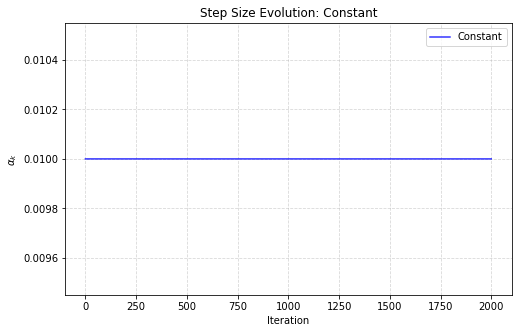

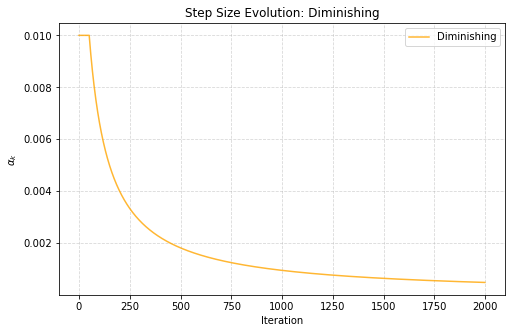

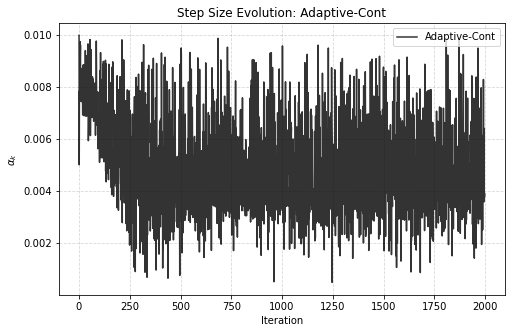

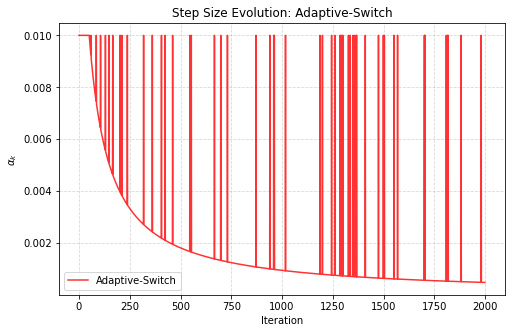

In [33]:
for name, (_, _, alphas) in results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, label=name, color=color_map[name], **line_kw)
    plt.xlabel("Iteration")
    plt.ylabel(r"$\alpha_k$")
    plt.title(f"Step Size Evolution: {name}")
    plt.legend()
    plt.grid(True, ls="--", alpha=0.5)
    plt.show()


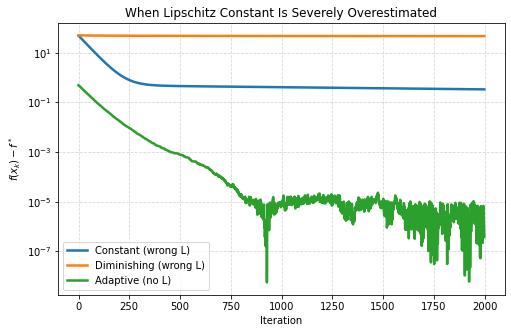

Iterations to reach f - f* <= 0.001:
Constant (wrong L)       : not reached
Diminishing (wrong L)    : not reached
Adaptive (no L)          : 452


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(0)

# ============================================================
# Problem: strongly convex quadratic
# ============================================================
A = np.array([[1.0, 0.0],
              [0.0, 100.0]])

L_true = 100.0
L_est  = 1e4      # severely overestimated Lipschitz constant

def f(x):
    return 0.5 * x @ A @ x

def grad(x):
    return A @ x

x_star = np.zeros(2)
x0 = np.array([1.0, 1.0])

# ============================================================
# Experiment parameters
# ============================================================
K = 2000
eps = 0.05        # small gradient error
rho = 0.0         # uncorrelated noise (clean demo)

# ============================================================
# Step size rules
# ============================================================
alpha_const = 1.0 / L_est   # badly underestimated step size

def alpha_diminishing(k, beta=50):
    return 1.0 / (L_est * (k + beta))

def alpha_adaptive_cont(rel_dk, amax=1.0 / L_true, amin=1e-4):
    return np.clip(amax / (1.0 + rel_dk), amin, amax)

# ============================================================
# Inexact gradient descent
# ============================================================
def run(method):
    rng = np.random.default_rng(0)
    e = np.zeros(2)

    def bounded_error():
        nonlocal e
        e = rho * e + np.sqrt(1 - rho**2) * rng.standard_normal(2)
        return eps * e / (np.linalg.norm(e) + 1e-8)

    x = x0.copy()
    g_prev = grad(x) + bounded_error()

    fvals = []

    for k in range(K):
        g = grad(x) + bounded_error()

        if method == "constant":
            alpha = alpha_const

        elif method == "diminishing":
            alpha = alpha_diminishing(k)

        elif method == "adaptive":
            rel_dk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g_prev) + 1e-8)
            alpha = alpha_adaptive_cont(rel_dk)

        x = x - alpha * g
        fvals.append(f(x))

        g_prev = g

    return np.array(fvals)

# ============================================================
# Run experiments
# ============================================================
results = {
    "Constant (wrong L)": run("constant"),
    "Diminishing (wrong L)": run("diminishing"),
    "Adaptive (no L)": run("adaptive"),
}

# ============================================================
# Plot: suboptimality
# ============================================================
plt.figure(figsize=(8, 5))
for name, fvals in results.items():
    plt.semilogy(fvals - f(x_star), label=name, linewidth=2.5)

plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("When Lipschitz Constant Is Severely Overestimated")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ============================================================
# Time-to-accuracy diagnostic
# ============================================================
target = 1e-3
print(f"Iterations to reach f - f* <= {target}:")
for name, fvals in results.items():
    idx = np.where(fvals - f(x_star) <= target)[0]
    if len(idx) == 0:
        print(f"{name:25s}: not reached")
    else:
        print(f"{name:25s}: {idx[0]}")

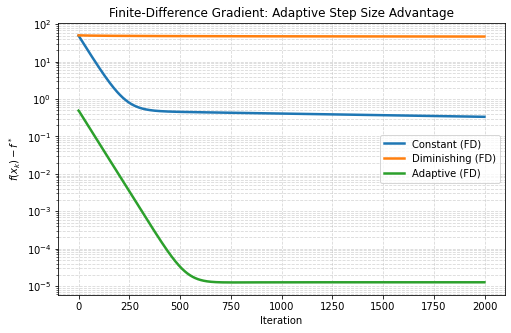

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem setup
# ============================================================
A = np.array([[1.0, 0.0],
              [0.0, 100.0]])

def f(x):
    return 0.5 * x @ A @ x

x_star = np.zeros(2)
x0 = np.array([1.0, 1.0])

# ============================================================
# Finite-difference gradient
# ============================================================
def fd_grad(x, h=1e-3):
    g = np.zeros_like(x)
    fx = f(x)
    for i in range(len(x)):
        e = np.zeros_like(x)
        e[i] = 1.0
        g[i] = (f(x + h * e) - fx) / h
    return g

# ============================================================
# Step size rules
# ============================================================
L_est = 1e4   # deliberately conservative
alpha_const = 1.0 / L_est

def alpha_diminishing(k, beta=50):
    return 1.0 / (L_est * (k + beta))

def alpha_adaptive_cont(rel_dk, amax=1e-2, amin=1e-4):
    return np.clip(amax / (1.0 + rel_dk), amin, amax)

# ============================================================
# Optimization loop
# ============================================================
def run(method, K=2000):
    x = x0.copy()
    g_prev = fd_grad(x)

    fvals = []

    for k in range(K):
        g = fd_grad(x)

        if method == "constant":
            alpha = alpha_const
        elif method == "diminishing":
            alpha = alpha_diminishing(k)
        elif method == "adaptive":
            rel_dk = np.linalg.norm(g - g_prev) / (np.linalg.norm(g_prev) + 1e-8)
            alpha = alpha_adaptive_cont(rel_dk)

        x = x - alpha * g
        fvals.append(f(x) - f(x_star))

        g_prev = g

    return np.array(fvals)

# ============================================================
# Run experiments
# ============================================================
results = {
    "Constant (FD)": run("constant"),
    "Diminishing (FD)": run("diminishing"),
    "Adaptive (FD)": run("adaptive"),
}

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(8, 5))
for name, vals in results.items():
    plt.semilogy(vals, label=name, linewidth=2.5)

plt.xlabel("Iteration")
plt.ylabel(r"$f(x_k) - f^*$")
plt.title("Finite-Difference Gradient: Adaptive Step Size Advantage")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()